# Anteproyecto - Computación Avanzada

### Tema: Aprendizaje de refuerzo en sistemas correlacionados en el tiempo usando redes neuronales

Participantes: 

        - Jefersson Manzanares Fernández
       
        - Esteban Porras Marín

Objetivos:

        - Modelar sistemas correlacionados
        
        - Modelar una red neuronal

        - Modelar un sistema combinado 

Marco teorico: 

Que es una red neuronal
Que es un  agente
Como se entrena una red neuronal
Idea de como implementar en el proyecto
        

### Cuanto tiempo dedicarle por semana?
- Pensaba dedicarle de 2 a 3 horas semanales

### Cuando pienso terminarlo?
- 

### Cual es el objetivo?


### Referencias:

Lapeyrolerie, M., Chapman, M. S., Norman, K. E. A., & Boettiger, C. (2022). Deep reinforcement learning for conservation decisions. Methods in Ecology and Evolution, 13, 2649–2662. https://doi.org/10.1111/2041-210X.13954

## Ejemplo basico
En este ejemplo se utiliza un ambiente de pesca basico y un agente.

In [13]:
from pesca_1D_env import Pesca1D
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

In [14]:
#Tasa de crecimiento inicial
r = 1

#Inicializa el ambiente
env = Pesca1D(r)

In [15]:
#Inicializa el modelo
agent = PPO("MlpPolicy", env, verbose=1)

#Entrena el modelo
agent.learn(total_timesteps=25000)

#Guarda el modelo
agent.save("ppo_pesca")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 38       |
| time/              |          |
|    fps             | 5256     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | 38.3         |
| time/                   |              |
|    fps                  | 1945         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0031400807 |
|    clip_fraction        | 0.024        |
|    clip_range           | 0.2          |
|    en

In [16]:
#Carga el modelo (para evitar correr el entrenamiento todas las veces)
agent = PPO.load("ppo_pesca")

In [17]:
#Cantidad de steps
N = 200

#Reinicia el sistema y obtiene la observacion inicial
obs, _ = env.reset()

#Listas para guardar la poblacion y el harvest
poblacion = np.zeros(N)
harvest = np.zeros(N)

for i in range(N):
    #El agente define una accion segun la observacion
    action, _ = agent.predict(obs, deterministic=True)

    #Calcula un step del environment segun la accion
    obs, reward, terminated, truncated, _ = env.step(action)

    #Registra la poblacion de cada paso
    poblacion[i] = env.unnormalize(obs[0])

    #Registra los rewards de cada paso
    harvest[i] = reward

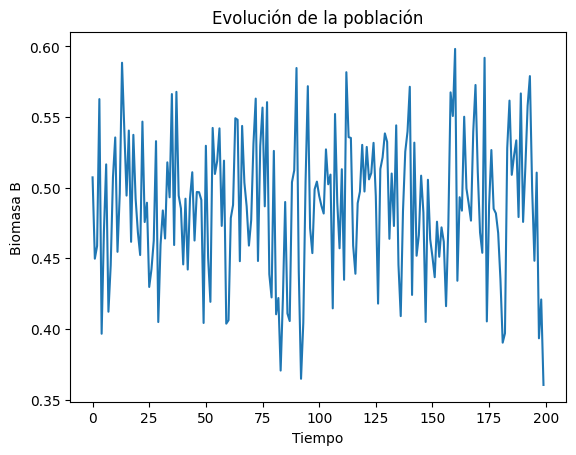

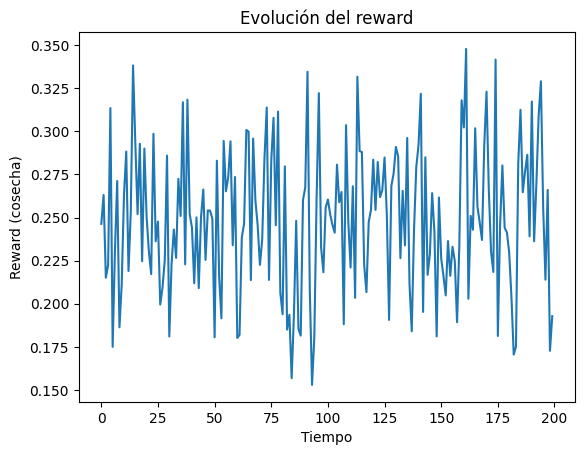

In [19]:
#Grafica la evolucion de la poblacion
plt.figure()
plt.plot(B_vals)
plt.xlabel("t")
plt.ylabel("Población")
plt.title("Evolución de la población")
plt.show()

#Grafica la evolucion del harvest
plt.figure()
plt.plot(rewards)
plt.xlabel("t")
plt.ylabel("Harvest")
plt.title("Evolución del Harvest")
plt.show()